In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import numpy as np
import jax
import jax.numpy as jnp

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# === Global Plotting Style ===
plt.style.use('tableau-colorblind10')
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 16,
    'axes.linewidth': 1.2,
    'axes.edgecolor': 'black',
    'xtick.major.size': 5,
    'ytick.major.size': 5
})

import config.config as config

import plotting_tools.basic_plotting_tools as plot_tools

import differential_geometry.aux_tools as aux

from differential_geometry.manifolds import Manifold
import differential_geometry.charts as charts
import differential_geometry.curves as curves
import differential_geometry.fields as fields

In [2]:
# === Define a manifold ==============================
surface_manifold = Manifold(
    param_dim=2, ambient_dim=3,
    embedding_func=aux.surface_embedding_factory(
        amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)
    ),
)

# === Define Charts ==================================
center_U = jnp.array([0.1, -0.7])
axes_U = (0.9, 1.5)
chart_U = charts.Chart(
    name="U", manifold=surface_manifold,
    boundary_curve=lambda lambdas: aux.boundary_ellipse_in_param_space(
        lambdas, center=center_U, axes=axes_U
    ), chart_map=aux.cartesian_chart_map
)

center_V = jnp.array([0.7, 0.3])
axes_V = (1.4, 0.9)
x_center_polar, y_center_polar = -1., -1.
chart_V = charts.Chart(
    name="V", manifold=surface_manifold,
    boundary_curve=lambda lambdas: aux.boundary_ellipse_in_param_space(
        lambdas, center=center_V, axes=axes_V
    ), chart_map=lambda params: aux.polar_chart_map(params, center=(x_center_polar, y_center_polar))
)

# === Define a point p ===============================
p_x, p_y = 0.15, 0.15
p_in_M = surface_manifold.embed(jnp.array([p_x, p_y]))

# === Define curves ==================================
curve_gamma = curves.Curve(
    manifold=surface_manifold, parametric_function=aux.wiggly_curve_factory(
        p_x, p_y, amplitude=jnp.pi/6, frequency=jnp.pi/1.4
    )
)
curve_delta = curves.Curve(
    manifold=surface_manifold, parametric_function=aux.arching_curve_factory(
        p_x, p_y, amplitude=jnp.pi/6, frequency=jnp.pi/3
    )
)
# curve_gamma = curves.Curve(
#     manifold=surface_manifold, parametric_function=aux.vertical_line_curve_factory(p_x, p_y)
# )
# curve_delta = curves.Curve(
#     manifold=surface_manifold, parametric_function=aux.circle_curve_factory(p_x, p_y)
# )

# === Define Fields ===================================
field_X = fields.Field(manifold=surface_manifold, vector_function=aux.circular_vector_field_parametric)
field_Y = fields.Field(manifold=surface_manifold, vector_function=aux.constant_direction_vector_field_parametric(
        direction=(0.0, 1.0)
    )
)

In [3]:
xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
grid_resolution_field = 16

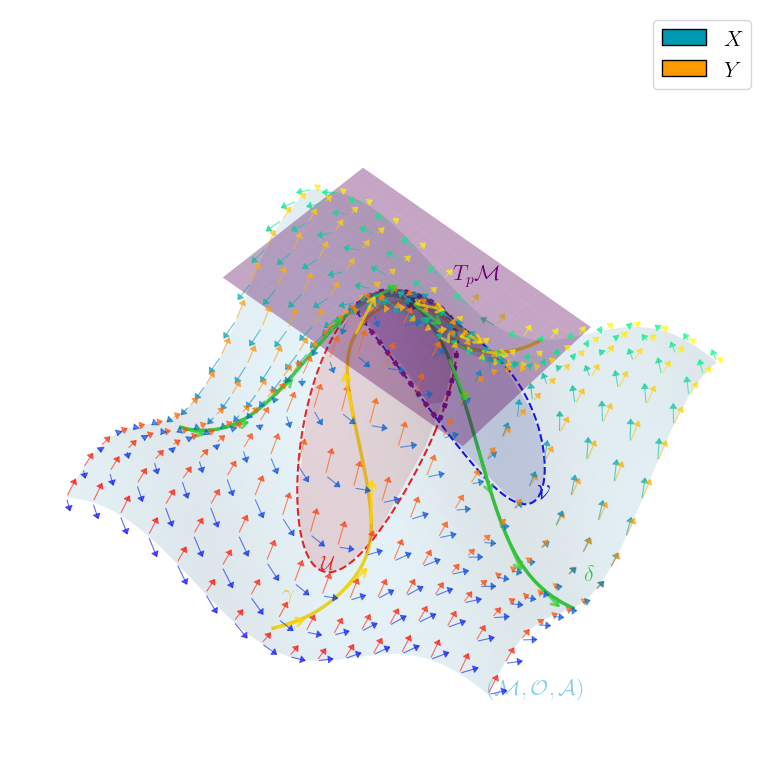

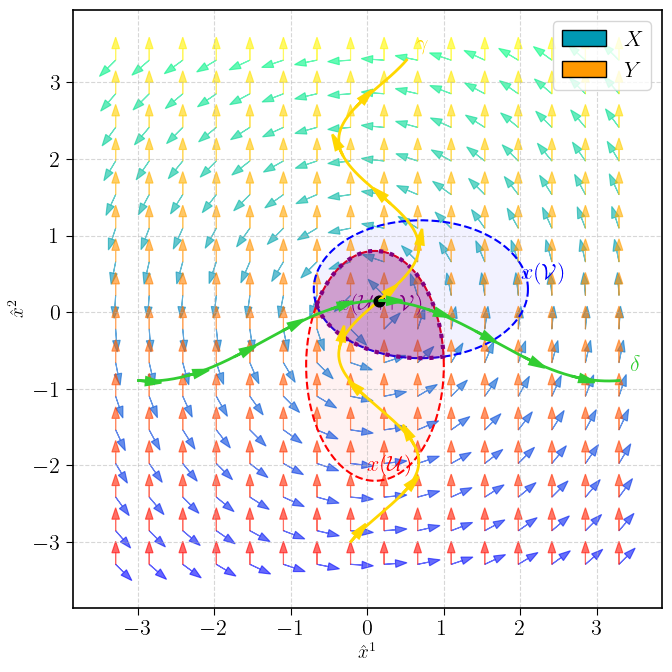

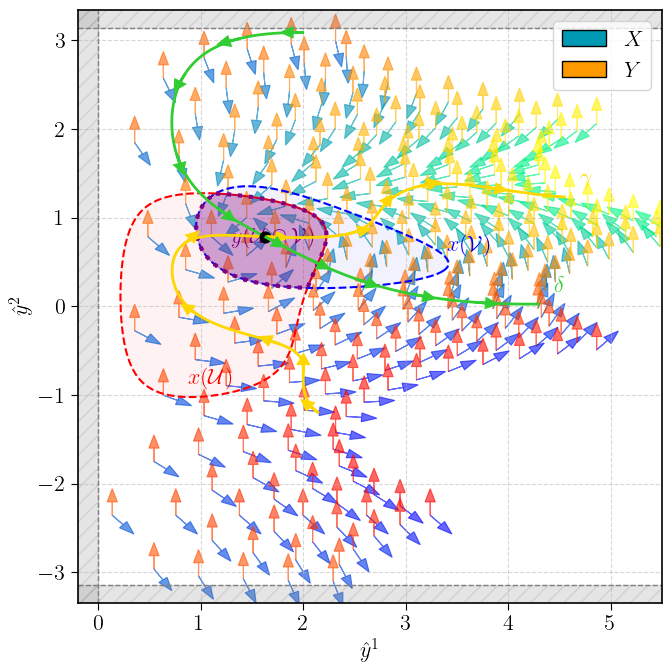

In [4]:
# === Manifold plot ===
fig, ax = plot_tools.create_3d_axis_for_manifold(xlim=(xmin, xmax), ylim=(ymin, ymax), zlim=(0, 2.5), axis_labels=None)

plot_tools.plot_manifold_surface(
    ax=ax, surface_manifold=surface_manifold, resolution=128, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
    color="skyblue", alpha=0.2, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)$",
    label_position="right", label_fontsize=16
)

p_xyz = p_in_M[0] if p_in_M.shape[0] == 1 else p_in_M
ax.scatter(*p_xyz, color="k", s=60)

p_xyz, t1, t2 = surface_manifold.tangent_plane_at(jnp.array([p_x, p_y]))
plot_tools.plot_tangent_plane(ax, p_xyz, t1, t2, size=1.8, color="purple", alpha=0.35)
ax.text(p_xyz[0] + 0.4, p_xyz[1] + 0.4, p_xyz[2] + 0.15, r"$T_p\mathcal{M}$", fontsize=16, color="purple")

plot_tools.plot_chart_region_manifold(
    ax=ax, surface_manifold=surface_manifold, chart=chart_U, color='red', n_points=128, linestyle='dashed', linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor='red', label=r"$\mathcal{U}$", label_position="bottom", label_fontsize=14
)

plot_tools.plot_chart_region_manifold(
    ax=ax, surface_manifold=surface_manifold, chart=chart_V, color='blue', n_points=128, linestyle='dashed', linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor='blue', label=r"$\mathcal{V}$", label_position="bottom", label_fontsize=14
)

plot_tools.plot_chart_intersection(
    ax=ax, surface_manifold=surface_manifold, chart1=chart_U, chart2=chart_V, color='purple', n_points=128, linestyle='dotted',
    linewidth=3.5, fill_surface=True, alpha=0.2, edgecolor='purple', label=None, # r"$\mathcal{U} \cap \mathcal{V}$"
    label_position="center", label_fontsize=14
)

plot_tools.plot_curve_on_manifold(
    ax=ax, curve=curve_gamma, lambda_range=(-jnp.pi, jnp.pi), color="gold", linewidth=2.5, show_tangents=True,
    tangent_step=30, tangent_scale=0.5, tangent_style=dict(
        mutation_scale=1.5, arrowstyle="->,head_length=3.,head_width=2.", lw=2.0, color="gold"
    ), tangent_method="finite_difference", # explore why this does not work correctly with autodiff
    label=r"$\gamma$", label_position="start", label_fontsize=16, label_offset=(0.1, 0.1, 0.3)
)

plot_tools.plot_curve_on_manifold(
    ax=ax, curve=curve_delta, lambda_range=(-jnp.pi, jnp.pi), color="limegreen", linewidth=2.5, show_tangents=True,
    tangent_step=30, tangent_scale=0.5, tangent_style=dict(
        mutation_scale=1.5, arrowstyle="->,head_length=3.,head_width=2.", lw=2.0, color="limegreen"
    ), tangent_method="finite_difference", # explore why this does not work correctly with autodiff,
    label=r"$\delta$", label_position="end", label_fontsize=16, label_offset=(0.1, 0.1, 0.3)
)

handle_X = plot_tools.plot_vector_field_on_manifold(
    ax, field=field_X, grid_resolution=grid_resolution_field, xlim=(xmin, xmax), ylim=(ymin, ymax), vector_scale=0.3,
    colormap="winter", label=r"$X$", return_legend_handle=True
)

handle_Y = plot_tools.plot_vector_field_on_manifold(
    ax, field=field_Y, grid_resolution=grid_resolution_field, xlim=(xmin, xmax), ylim=(ymin, ymax), vector_scale=0.3,
    colormap="autumn", label=r"$Y$", return_legend_handle=True
)

ax.legend(handles=[handle_X, handle_Y], loc="upper right", frameon=True)

ax.view_init(elev=50.0, azim=-60.0)
plt.tight_layout()
plt.show()


# === Chart U plot ===
fig, ax = plt.subplots(figsize=(7, 7))

p_coords = chart_U.map_to_chart(jnp.array([p_x, p_y]))
p_coords = p_coords[0] if p_coords.ndim == 2 and p_coords.shape[0] == 1 else p_coords
ax.scatter(*p_coords, color="black", s=60, zorder=5, label=r"$p$")

lambdas = jnp.linspace(0, 2 * jnp.pi, 500)
boundary_U_chart_U = chart_U.map_to_chart(chart_U.boundary_in_param_space(lambdas))
plot_tools.plot_chart_region_2D(ax, boundary=boundary_U_chart_U, color="red", label=r"$x(\mathcal{U})$", label_position="bottom")

lambdas = jnp.linspace(0, 2 * jnp.pi, 500)
boundary_V_chart_U = chart_U.map_to_chart(chart_V.boundary_in_param_space(lambdas))
plot_tools.plot_chart_region_2D(ax, boundary=boundary_V_chart_U, color="blue", label=r"$x(\mathcal{V})$", label_position="right")

intersection_U_cap_V_chart_U = aux.compute_chart_intersection(boundary_U_chart_U, boundary_V_chart_U)
plot_tools.plot_intersection_region_2D(ax, intersection_U_cap_V_chart_U, color="purple", label=r"$x(\mathcal{U} \cap \mathcal{V})$", label_position="center")

plot_tools.plot_curve_in_chart(ax, chart=chart_U, curve=curve_gamma, color="gold", label=r"$\gamma$", label_position="end")
plot_tools.plot_tangent_vectors_in_chart(
    ax, chart=chart_U, curve=curve_gamma, step=30, scale=0.3, color="gold", linewidth=1.8,
    head_width=0.1, head_length=0.2, zorder=5
)

plot_tools.plot_curve_in_chart(ax, chart=chart_U, curve=curve_delta, color="limegreen", label=r"$\delta$", label_position="end")
plot_tools.plot_tangent_vectors_in_chart(
    ax, chart=chart_U, curve=curve_delta, step=30, scale=0.3, color="limegreen", linewidth=1.8,
    head_width=0.1, head_length=0.2, zorder=5
)

xv, yv = jnp.linspace(xmin, xmax, grid_resolution_field), jnp.linspace(ymin, ymax, grid_resolution_field)
param_points = jnp.stack(jnp.meshgrid(xv, yv), axis=-1).reshape(-1, 2)
points_in_chart = chart_U.map_to_chart(param_points)

uX = field_X.evaluate_in_param_space(param_points)
uX /= jnp.linalg.norm(uX, axis=1, keepdims=True)
uY = field_Y.evaluate_in_param_space(param_points)
uY /= jnp.linalg.norm(uY, axis=1, keepdims=True)

handle_X = plot_tools.plot_vector_field_in_chart(ax, points_in_chart, uX, vector_scale=0.3, colormap="winter", label=r"$X$", return_legend_handle=True)
handle_Y = plot_tools.plot_vector_field_in_chart(ax, points_in_chart, uY, vector_scale=0.3, colormap="autumn", label=r"$Y$", return_legend_handle=True)
ax.legend(handles=[handle_X, handle_Y], loc="upper right", frameon=True)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel(r"$\hat{x}^1$", fontsize=14)
ax.set_ylabel(r"$\hat{x}^2$", fontsize=14)
plt.tight_layout()
plt.show()


# === Chart V plot ===
fig, ax = plt.subplots(figsize=(7, 7))

p_coords = chart_V.map_to_chart(jnp.array([p_x, p_y]))
p_coords = p_coords[0] if p_coords.ndim == 2 and p_coords.shape[0] == 1 else p_coords
ax.scatter(*p_coords, color="black", s=60, zorder=5, label=r"$p$")

lambdas = jnp.linspace(0, 2 * jnp.pi, 500)
boundary_U_chart_V = chart_V.map_to_chart(chart_U.boundary_in_param_space(lambdas))
plot_tools.plot_chart_region_2D(ax, boundary=boundary_U_chart_V, color="red", label=r"$x(\mathcal{U})$", label_position="bottom")

lambdas = jnp.linspace(0, 2 * jnp.pi, 500)
boundary_V_chart_V = chart_V.map_to_chart(chart_V.boundary_in_param_space(lambdas))
plot_tools.plot_chart_region_2D(ax, boundary=boundary_V_chart_V, color="blue", label=r"$x(\mathcal{V})$", label_position="right")

intersection_U_cap_V_chart_V = aux.compute_chart_intersection(boundary_U_chart_V, boundary_V_chart_V)
plot_tools.plot_intersection_region_2D(ax, intersection_U_cap_V_chart_V, color="purple", label=r"$y(\mathcal{U} \cap \mathcal{V})$", label_position="center")

plot_tools.plot_curve_in_chart(ax, chart=chart_V, curve=curve_gamma, color="gold", label=r"$\gamma$", label_position="end")
plot_tools.plot_tangent_vectors_in_chart(
    ax, chart=chart_V, curve=curve_gamma, step=30, scale=0.2, color="gold", linewidth=1.8,
    head_width=0.1, head_length=0.1, zorder=5
)

plot_tools.plot_curve_in_chart(ax, chart=chart_V, curve=curve_delta, color="limegreen", label=r"$\delta$", label_position="end")
plot_tools.plot_tangent_vectors_in_chart(
    ax, chart=chart_V, curve=curve_delta, step=30, scale=0.2, color="limegreen", linewidth=1.8,
    head_width=0.1, head_length=0.1, zorder=5
)

xv, yv = jnp.linspace(xmin, xmax, grid_resolution_field), jnp.linspace(ymin, ymax, grid_resolution_field)
param_points = jnp.stack(jnp.meshgrid(xv, yv), axis=-1).reshape(-1, 2)
points_in_chart = chart_V.map_to_chart(param_points)

uX = field_X.evaluate_in_param_space(param_points)
uX /= jnp.linalg.norm(uX, axis=1, keepdims=True)
uY = field_Y.evaluate_in_param_space(param_points)
uY /= jnp.linalg.norm(uY, axis=1, keepdims=True)

handle_X = plot_tools.plot_vector_field_in_chart(ax, points_in_chart, uX, vector_scale=0.3, colormap="winter", label=r"$X$", return_legend_handle=True)
handle_Y = plot_tools.plot_vector_field_in_chart(ax, points_in_chart, uY, vector_scale=0.3, colormap="autumn", label=r"$Y$", return_legend_handle=True)
ax.legend(handles=[handle_X, handle_Y], loc="upper right", frameon=True)

ax.set(xlim=(-0.2, 5.5), ylim=(-np.pi-0.2, np.pi+0.2),
       xlabel=r"$\hat{y}^1$", ylabel=r"$\hat{y}^2$")
ax.axvspan(-1, 0, color='grey', alpha=0.2, hatch='//')
ax.axhspan(np.pi, np.pi+1, color='grey', alpha=0.2, hatch='//')
ax.axhspan(-np.pi-1, -np.pi, color='grey', alpha=0.2, hatch='//')
ax.axhline(np.pi, color='gray', ls='--', lw=1)
ax.axhline(-np.pi, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# # === Prepare curve data (reduced resolution) ===
# lambda_vals = jnp.linspace(-jnp.pi, jnp.pi, 50)  # ⬅️ Reduced from 500 to 200
# curve_gamma_pts = surface_manifold.embed(curve_gamma.evaluate_in_param_space(lambda_vals))
# curve_delta_pts = surface_manifold.embed(curve_delta.evaluate_in_param_space(lambda_vals))

# # === Create figure ===
# xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi / 3
# ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi / 3

# fig, ax = plot_tools.create_3d_axis_for_manifold(
#     xlim=(xmin, xmax),
#     ylim=(ymin, ymax),
#     zlim=(0, 2.5),
#     axis_labels=None
# )

# # === Plot static surface (reduced resolution) ===
# plot_tools.plot_manifold_surface(
#     ax=ax,
#     surface_manifold=surface_manifold,
#     resolution=64,  # ⬅️ Reduced from 128 to 64
#     xmin=xmin,
#     xmax=xmax,
#     ymin=ymin,
#     ymax=ymax,
#     color="skyblue",
#     alpha=0.2,
#     edgecolor="none",
#     label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)$",
#     label_position="right",
#     label_fontsize=16
# )

# # === Plot chart regions ===
# plot_tools.plot_chart_region_manifold(
#     ax=ax, surface_manifold=surface_manifold, chart=chart_U,
#     color='red', linestyle='dashed', linewidth=1.5, fill_surface=True,
#     alpha=0.15, edgecolor='red', label=r"$\mathcal{U}$", label_position="bottom"
# )

# plot_tools.plot_chart_region_manifold(
#     ax=ax, surface_manifold=surface_manifold, chart=chart_V,
#     color='blue', linestyle='dashed', linewidth=1.5, fill_surface=True,
#     alpha=0.15, edgecolor='blue', label=r"$\mathcal{V}$", label_position="bottom"
# )

# plot_tools.plot_chart_intersection(
#     ax=ax, surface_manifold=surface_manifold, chart1=chart_U, chart2=chart_V,
#     color='purple', linestyle='dotted', linewidth=3.5, fill_surface=True,
#     alpha=0.2, edgecolor='purple', label=None, label_position="center"
# )

# # === Plot point and tangent plane ===
# p_xyz = surface_manifold.embed(jnp.array([[p_x, p_y]]))[0]
# ax.scatter(p_xyz[0], p_xyz[1], p_xyz[2], color="k", s=60)

# p_xyz, t1, t2 = aux.compute_tangent_plane(surface_manifold, jnp.array([p_x, p_y]))
# plot_tools.plot_tangent_plane(ax, p_xyz, t1, t2, size=1.8, color="purple", alpha=0.35)

# # === Initialize curves ===
# line_gamma, = ax.plot([], [], [], color="gold", linewidth=2.5, label=r"$\gamma$")
# line_delta, = ax.plot([], [], [], color="limegreen", linewidth=2.5, label=r"$\delta$")

# # === Animation update ===
# def update(frame):
#     ax.view_init(elev=50, azim=-60 + frame * 1.0)  # ⬅️ Slightly faster rotation

#     line_gamma.set_data(curve_gamma_pts[:frame, 0], curve_gamma_pts[:frame, 1])
#     line_gamma.set_3d_properties(curve_gamma_pts[:frame, 2])

#     line_delta.set_data(curve_delta_pts[:frame, 0], curve_delta_pts[:frame, 1])
#     line_delta.set_3d_properties(curve_delta_pts[:frame, 2])

#     return line_gamma, line_delta

# # === Create animation ===
# frames = len(lambda_vals)  # ⬅️ 200 frames instead of 500
# ani = animation.FuncAnimation(
#     fig, update, frames=frames, interval=40, blit=False
# )

# # === Save animation ===
# ani.save("manifold_animation.mp4", fps=30, bitrate=1800)

# plt.show()